# Deconvolution of Microscopy Images by Learning the Point-Spread Function

A microscope blurs. If you knew exactly *how* it blurred — its point-spread
function — you could partly undo the damage. Usually you don't.

This notebook trains a small convolutional network to look at a blurred
micrograph and estimate the **aberration that produced it**, expressed as eight
Zernike coefficients. From those eight numbers the PSF is reconstructed in closed
form, a regularized inverse filter is built, and the image is sharpened.

The pipeline has two stages, and **only the first is learned**:

> blurred image → `[CNN]` → 8 Zernike coefficients → `[closed-form Wiener inverse]` → sharpened image

Nothing here is a black box except those eight numbers.

---

### A note on ordering

This notebook follows the **physics**, not the usual machine-learning recipe. We
build the forward model first, watch naive inversion fail, understand *why* it
fails, and only then reach for a network — to supply the one thing the classical
methods need and cannot get.

| Part | Question |
|---|---|
| 1 | How does a microscope blur an image? |
| 2 | Why can't we simply divide the blur back out? |
| 3 | Can a network estimate the PSF from the blurred image alone? |
| 4 | Does the estimated PSF actually sharpen the image? |
| 5 | Does any of this survive contact with real data? |
| 6 | What would a real system need that this doesn't have? |

## Part 0 — Setup

`QUICK` controls the scale of everything below. **The committed outputs of this
notebook were produced with `QUICK = True` on a CPU**, which trains for a few
hundred steps instead of tens of thousands — enough to prove the pipeline runs
end to end, not enough to produce good science.

Set `QUICK = False` and re-run on a GPU for the real numbers. That takes roughly
an hour on an RTX 5070 Ti.

In [1]:
QUICK = True   # <-- set False for the full run on a GPU

%matplotlib inline

import torch
import matplotlib.pyplot as plt

from deconv.optics import (
    Optics, zernike_basis, psf_from_coeffs, center_crop, otf_from_psf,
    convolve_fft, apply_wiener, naive_inverse, NOLL_INDICES, NOLL_NAMES,
)
from deconv.data import (
    sample_coeffs, make_beads, make_extended, make_objects, add_noise,
    normalise_image, normalise_coeffs, denormalise_coeffs, NoiseConfig,
    synth_batch, load_real_slices, load_training_pool, load_held_out,
    HELD_OUT, TRAIN_REAL,
)
from deconv.model import PSFNet, TrainConfig, train, build_input, predict_coeffs, \
    count_parameters, coefficient_errors
from deconv.metrics import psnr, ssim, frc, frc_resolution_nm
import deconv.viz as viz

SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("WARNING: no GPU found. Training will be slow; keep QUICK = True.")
print(f"device: {device}   |   QUICK: {QUICK}")

SIZE   = 64  if QUICK else 128
STEPS  = 600 if QUICK else 30_000
BATCH  = 16  if QUICK else 64


def quick_warning():
    # Banner so undertrained QUICK-mode results are never mistaken for real ones.
    if QUICK:
        print("!" * 72)
        print("QUICK MODE: trained for a few hundred steps. The numbers below are")
        print("NOT meaningful science - the model is barely above chance and may")
        print("score worse than doing nothing. Set QUICK = False and re-run on a")
        print("GPU for real results. Only the PIPELINE is being demonstrated here.")
        print("!" * 72)
        print()

device: cpu   |   QUICK: True


### The optical configuration

These are the numbers a microscopist would recognise: a high-NA oil-immersion
objective imaging GFP onto an sCMOS camera at 100×.

The one that matters most is the **pixel size**. To sample the image faithfully
it must be smaller than $\lambda / 4\mathrm{NA}$ — otherwise the detector, not
the optics, sets the resolution.

In [2]:
optics = Optics(na=1.4, wavelength_nm=520.0, pixel_nm=65.0, grid=256)

print(f"NA                  {optics.na}")
print(f"wavelength          {optics.wavelength_nm:.0f} nm  (GFP emission)")
print(f"pixel size          {optics.pixel_nm:.0f} nm")
print()
print(f"Airy radius         {optics.airy_radius_nm:6.1f} nm  = {optics.airy_radius_px:.2f} px")
print(f"PSF FWHM            {optics.fwhm_nm:6.1f} nm  = {optics.fwhm_px:.2f} px")
print(f"OTF cutoff          {optics.cutoff_per_um:6.3f} /um")
print(f"Nyquist pixel limit {optics.nyquist_pixel_nm:6.1f} nm")
print()
print(f"sampling factor     {optics.sampling_factor:.2f}x inside Nyquist "
      f"({'OK' if optics.sampling_factor > 1 else 'UNDERSAMPLED'})")
print(f"pupil radius        {optics.pupil_radius_px:.1f} px on a {optics.grid} grid")

NA                  1.4
wavelength          520 nm  (GFP emission)
pixel size          65 nm

Airy radius          226.6 nm  = 3.49 px
PSF FWHM             189.4 nm  = 2.91 px
OTF cutoff           5.385 /um
Nyquist pixel limit   92.9 nm

sampling factor     1.43x inside Nyquist (OK)
pupil radius        44.8 px on a 256 grid


---
## Part 1 — How a microscope blurs

### 1.1 The wavefront

Light from a point in the sample arrives at the objective's back aperture as a
wavefront. In a perfect instrument that wavefront is flat. In a real one it is
deformed — by the objective, by the coverslip, by the refractive-index mismatch
between immersion oil and specimen.

We describe the deformation $W(\rho,\theta)$ as a sum of **Zernike polynomials**,
which are the natural orthogonal basis on a circular aperture:

$$W(\rho,\theta) \;=\; \sum_j c_j\, Z_j(\rho,\theta)$$

Each $Z_j$ is a named aberration a microscopist would recognise, and each $c_j$
is its strength in **waves**. Those eight $c_j$ are the entire label the network
will learn to predict.

We use **Noll indexing**, $j = 4 \dots 11$. Piston ($j{=}1$) is an invisible
constant phase; tip and tilt ($j{=}2,3$) merely translate the image. Neither
affects image quality, so both are excluded.

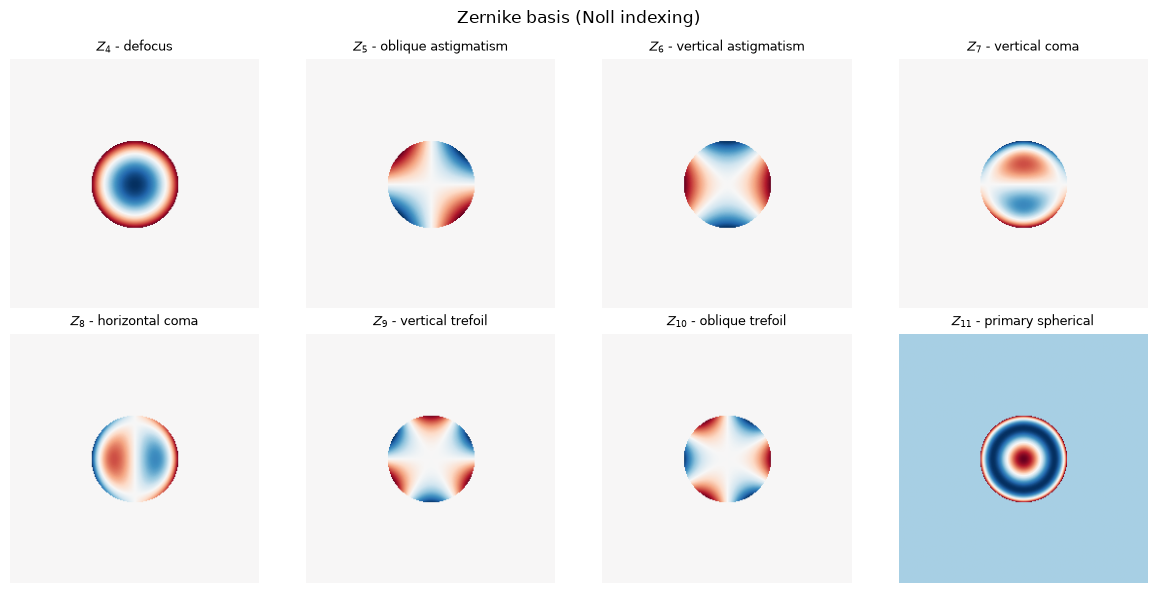

In [3]:
basis, mask = zernike_basis(optics, device=device)
viz.plot_zernike_gallery(basis, mask)
plt.show()

### 1.2 Checking the basis before trusting it

Zernike indexing conventions disagree with each other. Noll numbers the modes
one way; OSA/ANSI numbers them differently. Published tables contradict each
other — several consulted while building this notebook disagreed *internally*.

This matters more than it sounds. If the convention is wrong, every training
label is wrong, the loss still falls smoothly, and the error surfaces only as a
puzzling final result. So we verify the basis is genuinely orthonormal before
using it:

$$\frac{1}{\pi}\int_{\rho \le 1} Z_i Z_j \, \rho \,d\rho \,d\theta = \delta_{ij}$$

In [4]:
flat = (basis * mask).reshape(len(NOLL_INDICES), -1)
gram = (flat @ flat.T) / mask.sum()

off_diagonal = (gram - torch.diag(gram.diag())).abs().max().item()
print(f"diagonal   (should be 1): {[f'{v:.3f}' for v in gram.diag().tolist()]}")
print(f"max off-diagonal (should be 0): {off_diagonal:.4f}")
assert off_diagonal < 0.05, "basis is not orthonormal - check the Zernike convention"
print("\nOK - the basis is orthonormal, so the labels mean what we think they mean.")

diagonal   (should be 1): ['1.001', '1.006', '0.997', '1.002', '1.002', '1.002', '1.002', '1.002']
max off-diagonal (should be 0): 0.0062

OK - the basis is orthonormal, so the labels mean what we think they mean.


### 1.3 From wavefront to PSF

The pupil function combines the aperture $A(\rho)$ with the wavefront phase:

$$P(\rho,\theta) = A(\rho)\,e^{\,i 2\pi W(\rho,\theta)}$$

The image of a point source is the squared magnitude of the pupil's Fourier
transform:

$$h = \bigl|\mathcal{F}\{P\}\bigr|^2$$

With every $c_j = 0$ this reduces to the **Airy disc** — the diffraction limit.
Note where its first dark ring falls: $0.61\lambda/\mathrm{NA}$, the classical
resolution limit, emerging from the arithmetic rather than being put in by hand.

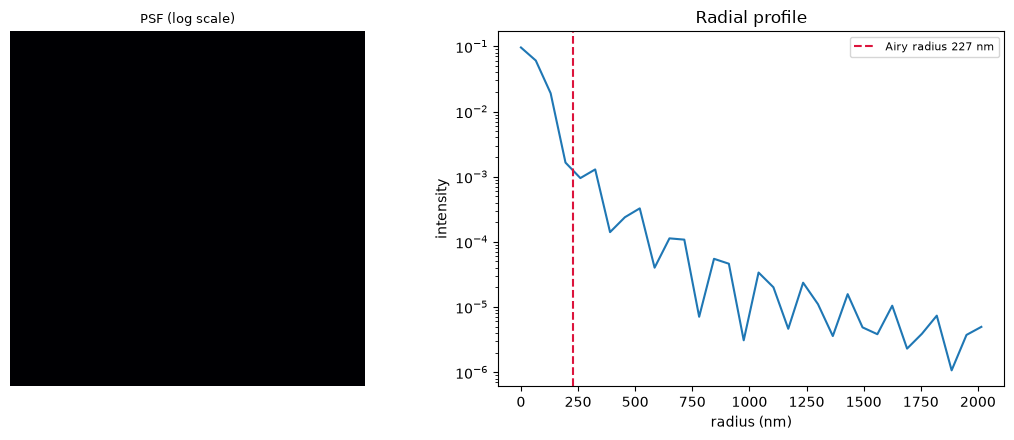

predicted first dark ring: 226.6 nm (3.49 px) - compare the dashed line above


In [5]:
perfect = psf_from_coeffs(torch.zeros(1, 8, device=device), basis, mask)[0]
viz.plot_psf_and_profile(perfect, optics)
plt.show()

print(f"predicted first dark ring: {optics.airy_radius_nm:.1f} nm "
      f"({optics.airy_radius_px:.2f} px) - compare the dashed line above")

### 1.4 What each aberration does to a point

Give each mode a modest amount of aberration, one at a time, and watch the point
source smear in its own characteristic way. Coma grows a tail; astigmatism
stretches along an axis; spherical aberration pushes energy out of the core into
a halo.

These shapes are the *only* evidence the network will get.

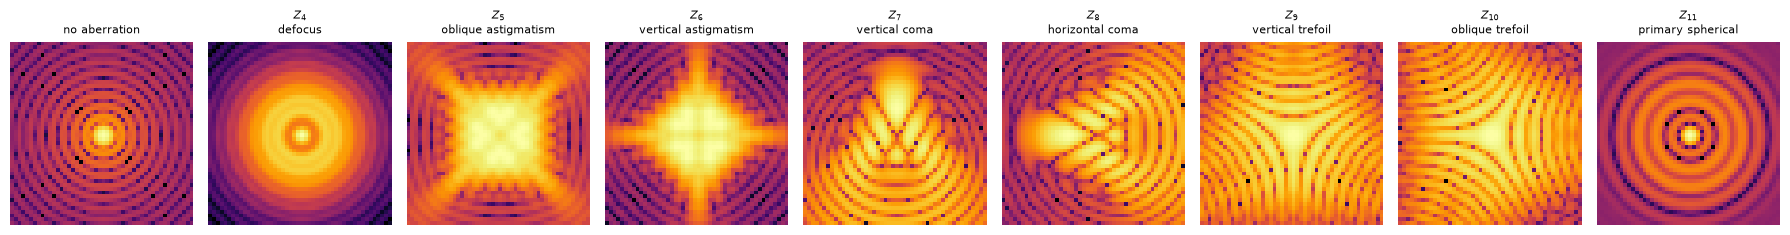

In [6]:
gallery, titles = [], ["no aberration"]
gallery.append(torch.zeros(8, device=device))
for idx, j in enumerate(NOLL_INDICES):
    c = torch.zeros(8, device=device)
    c[idx] = 0.4
    gallery.append(c)
    titles.append(f"$Z_{{{j}}}$\n{NOLL_NAMES[j]}")

psfs = psf_from_coeffs(torch.stack(gallery), basis, mask)
viz.plot_psf_gallery(psfs, titles)
plt.show()

### 1.5 The transfer function, and the hard wall

Convolution in real space is multiplication in Fourier space, so the blur is
easier to understand there. The **optical transfer function** is the Fourier
transform of the PSF:

$$Y(f) = H(f)\,O(f) + N(f)$$

$H(f)$ has a property with severe consequences: it is **exactly zero** above

$$f_c = \frac{2\,\mathrm{NA}}{\lambda}$$

Above that frequency the microscope transmitted *nothing*. Not "a little", not
"attenuated" — nothing. Aberrated transfer functions have additional zeros
*inside* the passband as well.

Everything difficult about deconvolution follows from this.

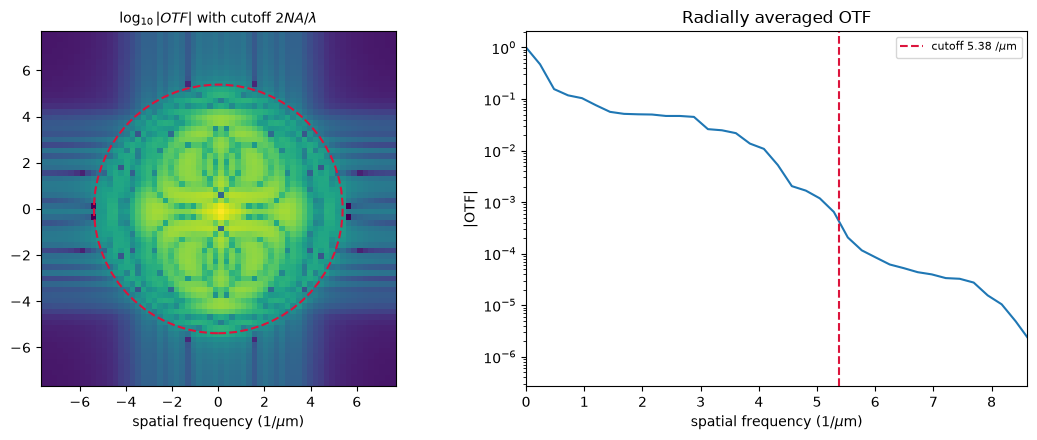

In [7]:
aberrated = torch.zeros(1, 8, device=device)
aberrated[0, 2] = 0.4   # vertical astigmatism
aberrated[0, 7] = 0.3   # spherical

psf_ab = center_crop(psf_from_coeffs(aberrated, basis, mask), SIZE)
viz.plot_otf(otf_from_psf(psf_ab)[0], optics)
plt.show()

### 1.6 The complete forward model

Object, convolved with the PSF, plus noise. The noise has two parts, both real:
**shot noise**, because light arrives as discrete photons and counting is
Poisson; and **read noise**, added by the camera electronics.

Photon counts matter enormously and we will return to them in Part 2.

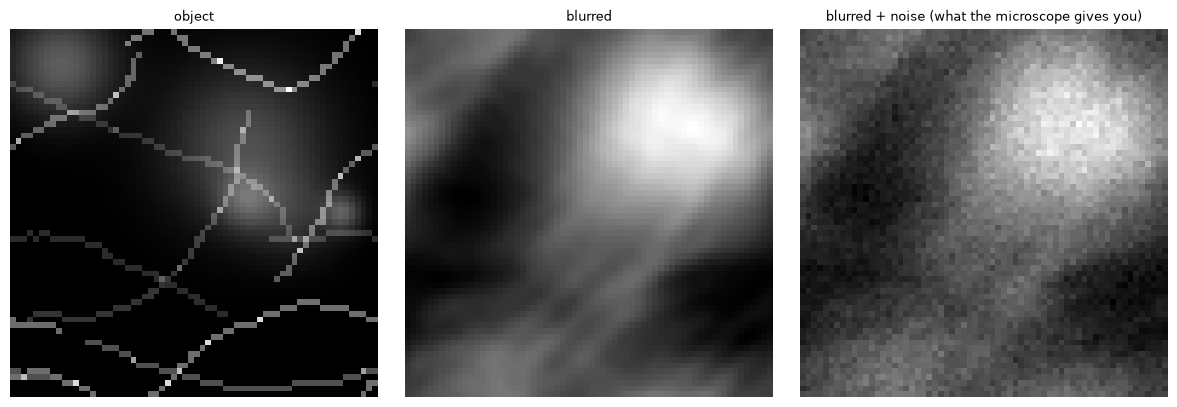

aberration that produced this blur (waves):
  Z4   defocus                +0.170
  Z5   oblique astigmatism    +0.252
  Z6   vertical astigmatism   -0.324
  Z7   vertical coma          +0.471
  Z8   horizontal coma        -0.111
  Z9   vertical trefoil       -0.090
  Z10  oblique trefoil        +0.392
  Z11  primary spherical      +0.251


In [8]:
g = torch.Generator(device=device); g.manual_seed(SEED)

obj = make_extended(1, SIZE, generator=g, device=device)
c_true = sample_coeffs(1, generator=g, device=device)
psf_true = center_crop(psf_from_coeffs(c_true, basis, mask), SIZE)
blurred = convolve_fft(obj, otf_from_psf(psf_true))
noisy = add_noise(blurred, peak_photons=800.0, read_sigma=2.0, generator=g)

viz.plot_forward_model(normalise_image(obj)[0], normalise_image(blurred)[0],
                       normalise_image(noisy)[0])
plt.show()

print("aberration that produced this blur (waves):")
for idx, j in enumerate(NOLL_INDICES):
    print(f"  Z{j:<3d} {NOLL_NAMES[j]:<22s} {c_true[0, idx]:+.3f}")

---
## Part 2 — Why you can't simply divide the blur out

### 2.1 The obvious thing, and why it explodes

If $Y = H \cdot O$, then surely $O = Y / H$?

Try it. The result is not a slightly noisy image — it is complete garbage, with
no trace of the original. Watch:

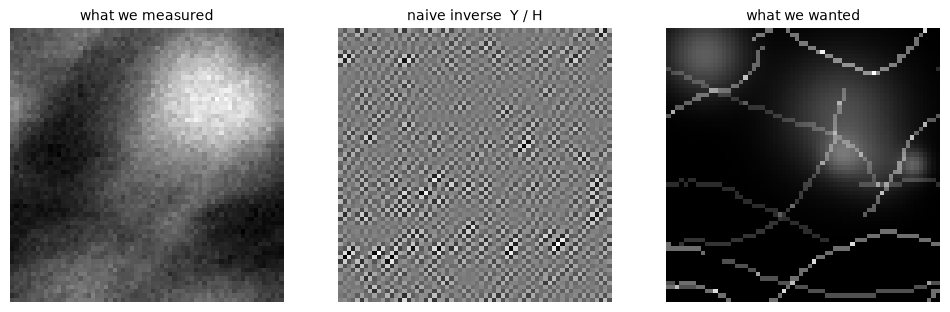

PSNR of the naive inverse: 7.40 dB
PSNR of just leaving it blurred: 10.01 dB


In [9]:
otf_true = otf_from_psf(psf_true)
naive = naive_inverse(noisy, otf_true)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [normalise_image(noisy)[0], normalise_image(naive)[0], normalise_image(obj)[0]],
    ["what we measured", "naive inverse  Y / H", "what we wanted"],
):
    ax.imshow(img.cpu(), cmap="gray"); ax.set_title(title, fontsize=10); ax.axis("off")
plt.show()

print(f"PSNR of the naive inverse: {psnr(normalise_image(naive), normalise_image(obj)):.2f} dB")
print(f"PSNR of just leaving it blurred: {psnr(normalise_image(noisy), normalise_image(obj)):.2f} dB")

### 2.2 Why

Write out what division actually does to the measurement:

$$\frac{Y}{H} = \frac{H \cdot O + N}{H} = O + \frac{N}{H}$$

The signal comes back perfectly. But so does $N/H$ — and where $H \to 0$, that
term diverges. Above the cutoff $H$ is zero, so we are dividing noise by nothing
and amplifying it without bound.

The information at those frequencies is *gone*. No algorithm recovers it. The
best we can do is avoid amplifying noise in its place.

### 2.3 Regularization

The Wiener filter replaces division with something that degrades gracefully:

$$G(f) = \frac{H^*(f)}{|H(f)|^2 + \lambda}$$

Where the signal is strong ($|H|^2 \gg \lambda$) this approaches $1/H$ and
inverts the blur. Where the signal vanishes ($|H|^2 \ll \lambda$) it rolls
smoothly to zero instead of exploding. That single $+\lambda$ is what makes an
inverse exist at all.

$\lambda$ is not free — it buys stability with resolution:

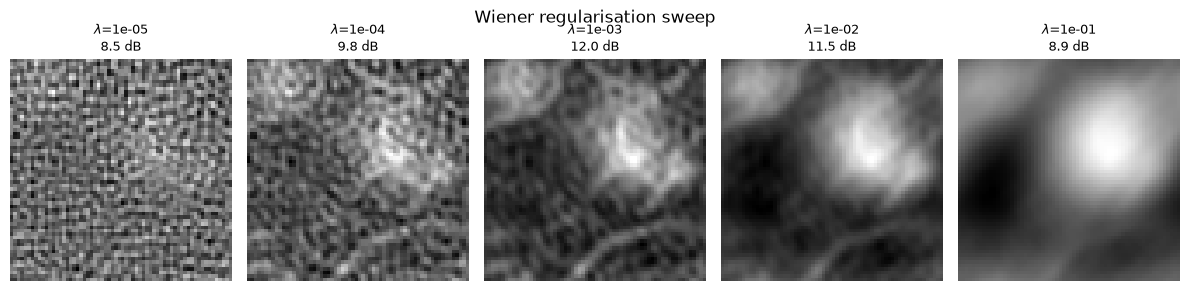

too little regularisation -> noise;  too much -> blur.  The optimum is in between.


In [10]:
regs = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
truth = normalise_image(obj)
images, scores = [], []
for r in regs:
    rec = normalise_image(apply_wiener(noisy, otf_true, r))
    images.append(rec[0]); scores.append(psnr(rec, truth))

viz.plot_lambda_sweep(images, regs, scores)
plt.show()
print("too little regularisation -> noise;  too much -> blur.  The optimum is in between.")

### 2.4 Deconvolution cannot create photons

A caveat usually skipped, and worth being honest about.

Deconvolution redistributes information that is present in the measurement. If
the measurement is starved of photons, there is nothing to redistribute. Below
we sweep the photon budget and deconvolve each time **with the true PSF** — the
best case possible.

At low photon counts the gain is not small. It is *absent*.

    30 photons: blurred  9.99 dB -> deconvolved  9.52 dB  (gain -0.47 dB)
   100 photons: blurred 10.04 dB -> deconvolved 10.74 dB  (gain +0.70 dB)
   300 photons: blurred 10.99 dB -> deconvolved 12.96 dB  (gain +1.97 dB)
  1000 photons: blurred  9.82 dB -> deconvolved 13.16 dB  (gain +3.34 dB)
  3000 photons: blurred  9.65 dB -> deconvolved 12.96 dB  (gain +3.31 dB)
 10000 photons: blurred  9.97 dB -> deconvolved 13.42 dB  (gain +3.45 dB)


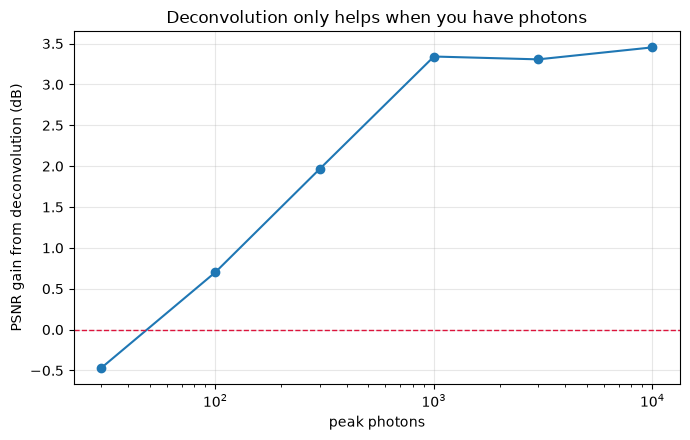

In [11]:
photon_levels = [30, 100, 300, 1000, 3000, 10000]
gains = []
for ph in photon_levels:
    gg = torch.Generator(device=device); gg.manual_seed(1)
    y = add_noise(blurred, peak_photons=float(ph), read_sigma=2.0, generator=gg)
    base = psnr(normalise_image(y), truth)
    best = max(psnr(normalise_image(apply_wiener(y, otf_true, r)), truth)
               for r in [1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1])
    gains.append(best - base)
    print(f"{ph:6d} photons: blurred {base:5.2f} dB -> deconvolved {best:5.2f} dB  "
          f"(gain {best - base:+5.2f} dB)")

viz.plot_gain_vs_photons([float(p) for p in photon_levels], gains)
plt.show()

### 2.5 The problem

Every method in this part used `otf_true` — the exact transfer function that
produced the blur.

On a real microscope you do not have it. You could measure it with a
sub-resolution bead, but that is a separate experiment under separate conditions,
and aberration drifts with depth, temperature and specimen.

**This is the gap the network fills.** Not the deconvolution — that is settled
mathematics. The missing PSF.

---
## Part 3 — Estimating the PSF from the blurred image

### 3.1 Why this is learnable at all

Every aberration leaves a *structured* signature. Astigmatism stretches features
along one axis; coma adds a directional tail; spherical aberration drains the
core into a halo. Those signatures are consistent across the whole field, because
we assume the PSF does not vary with position.

So the task is: read the whole image, output eight numbers. That is a **global**
regression, which is why the network average-pools over the entire field before
its final layer rather than predicting anything spatially.

### 3.2 Training data

We simulate. Draw random Zernike coefficients, build the PSF, convolve a random
object, add noise — and we have a perfectly labelled example. Infinitely many,
never repeating, no dataset on disk.

Objects are half **beads** (sub-diffraction points, where the PSF is directly
visible) and half **extended structures** (filaments and blobs). Beads alone
would be a trap: sparse impulses look nothing like biological texture, and a
bead-only model transfers poorly to real images.

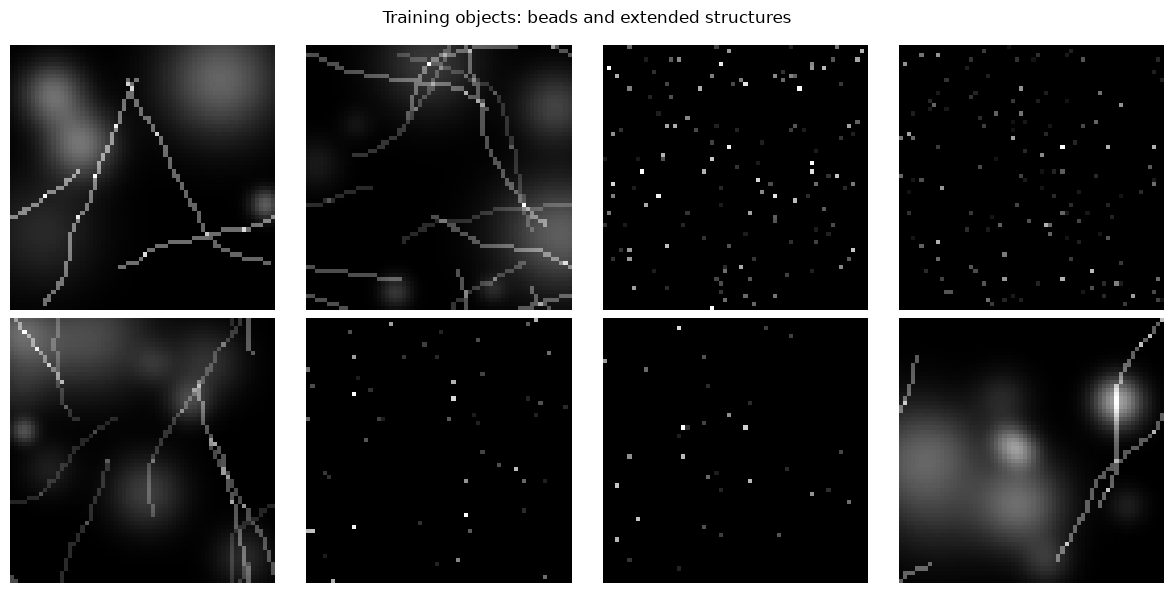

In [12]:
g = torch.Generator(device=device); g.manual_seed(SEED)
demo = make_objects(8, SIZE, bead_fraction=0.5, generator=g, device=device)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img in zip(axes.flat, demo):
    ax.imshow(normalise_image(img).cpu(), cmap="gray"); ax.axis("off")
fig.suptitle("Training objects: beads and extended structures", fontsize=12)
plt.tight_layout(); plt.show()

### 3.3 The network

A small convolutional stack, global average pooling, and a regression head onto
eight coefficients. Two input variants, which we will compare:

- **image** — the blurred image alone
- **image + spectrum** — the image plus its log power spectrum

The second exists because the transfer function's signature is more directly
visible in Fourier space than in the image. Whether that helps in practice is an
empirical question, and Part 3.6 answers it.

In [13]:
model_a = PSFNet("image").to(device)
print(f"parameters: {count_parameters(model_a):,}")
print(model_a)

parameters: 2,377,960
PSFNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace

### 3.4 Gate: can it overfit eight images?

Before any real training, a standard and extremely cheap check.

Take one small batch and train until the network memorises it. If the loss does
not collapse to near zero, something is broken — the labels, the gradient path,
the optimiser — and no amount of real training will fix it. Debugging here costs
seconds; debugging after a failed multi-hour run costs an afternoon.

In [14]:
gg = torch.Generator(device=device); gg.manual_seed(1)
x_fix, c_fix, _ = synth_batch(8, SIZE, optics, basis, mask, generator=gg, device=device,
                              noise=NoiseConfig(800, 2000, 1.0, 2.0))
inp = build_input(x_fix, "image")
tgt = normalise_coeffs(c_fix)

probe = PSFNet("image").to(device)
opt = torch.optim.AdamW(probe.parameters(), lr=3e-3)
for step in range(301):
    loss = torch.nn.functional.mse_loss(probe(inp), tgt)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if step % 100 == 0:
        print(f"  step {step:4d}   loss {loss.item():.2e}")

print(f"\nfinal loss {loss.item():.2e}")
assert loss.item() < 1e-3, "GATE FAILED - the training path is broken, stop here"
print("GATE PASSED - the network can fit the labels; proceed to real training.")

  step    0   loss 3.08e-01


  step  100   loss 7.41e-07


  step  200   loss 1.17e-10


  step  300   loss 5.82e-11

final loss 5.82e-11
GATE PASSED - the network can fit the labels; proceed to real training.


### 3.5 Training

Both variants, identical in every respect except the input representation.

In [15]:
cfg = TrainConfig(steps=STEPS, batch=BATCH, size=SIZE, seed=SEED,
                  warmup=max(10, STEPS // 60), log_every=max(1, STEPS // 30))

results, models = {}, {}
for variant in ["image", "image+spectrum"]:
    torch.manual_seed(SEED)
    model = PSFNet(variant).to(device)
    out = train(model, optics, basis, mask, cfg, device=device, progress=False)
    results[variant] = (out.steps, out.losses)
    models[variant] = model
    print(f"{variant:16s} final loss {out.final_loss:.4f}")

image            final loss 0.2916


image+spectrum   final loss 0.2677


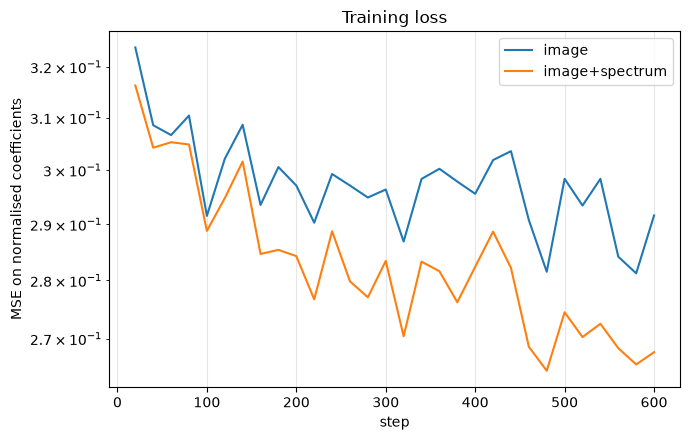

In [16]:
viz.plot_loss_curves(results)
plt.show()

### 3.6 Which input representation wins, and which modes are hard?

Error is reported in **waves**, per aberration mode. For reference, predicting
zero for everything would give roughly 0.25 waves of error, so anything near that
means the model has learned nothing about that mode.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
QUICK MODE: trained for a few hundred steps. The numbers below are
NOT meaningful science - the model is barely above chance and may
score worse than doing nothing. Set QUICK = False and re-run on a
GPU for real results. Only the PIPELINE is being demonstrated here.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



image            overall MAE 0.2135 waves


image+spectrum   overall MAE 0.1969 waves

chance level (predicting the mean): ~0.250 waves
better variant: image+spectrum


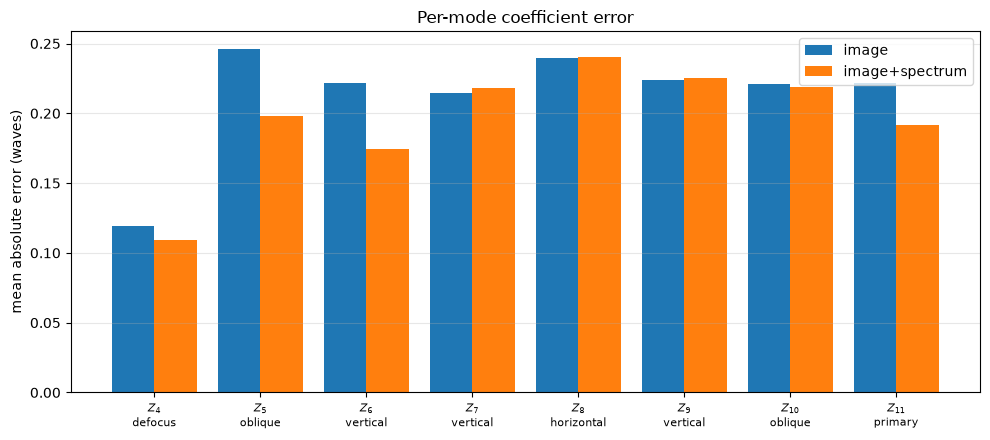

In [17]:
quick_warning()

errors, overall = {}, {}
for variant, model in models.items():
    per_mode, mae = coefficient_errors(model, optics, basis, mask,
                                       batch=64 if QUICK else 256, size=SIZE,
                                       device=device)
    errors[variant] = per_mode
    overall[variant] = mae.item()
    print(f"{variant:16s} overall MAE {mae.item():.4f} waves")

print(f"\nchance level (predicting the mean): ~{0.5 * 0.5:.3f} waves")
best_variant = min(overall, key=lambda k: overall[k])
print(f"better variant: {best_variant}")

viz.plot_per_mode_error(errors)
plt.show()

---
## Part 4 — Does the estimate actually sharpen the image?

Low coefficient error is reassuring but it is not the point. The question is
whether the *image* gets better.

We compare four things on the same measurement:

| | PSF used | meaning |
|---|---|---|
| blurred | — | do nothing |
| wrong PSF | aberration-free Airy | what you'd do with no information |
| **predicted PSF** | **the network's estimate** | **what this notebook is for** |
| true PSF | the one that made the blur | the best achievable — an oracle |

The oracle is not achievable in practice; it is the ceiling. The gap below it is
what the estimate costs you. The gap above the wrong-PSF baseline is what it
buys you.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
QUICK MODE: trained for a few hundred steps. The numbers below are
NOT meaningful science - the model is barely above chance and may
score worse than doing nothing. Set QUICK = False and re-run on a
GPU for real results. Only the PIPELINE is being demonstrated here.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



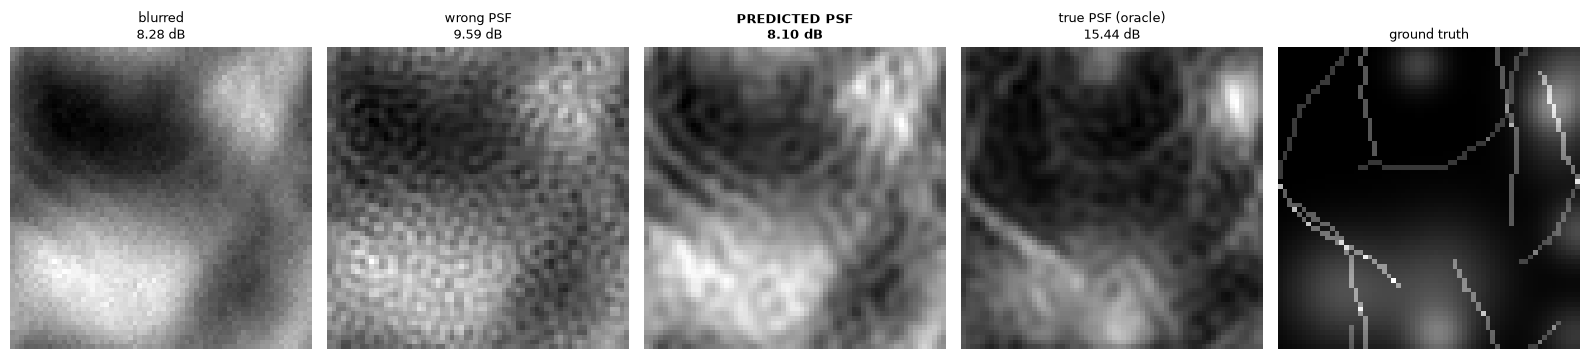

coefficient   true     predicted   error
  Z4   defocus                +0.339   +0.281   0.057
  Z5   oblique astigmatism    +0.325   +0.002   0.323
  Z6   vertical astigmatism   -0.080   -0.081   0.001
  Z7   vertical coma          +0.152   -0.009   0.161
  Z8   horizontal coma        +0.399   +0.012   0.387
  Z9   vertical trefoil       -0.135   +0.021   0.156
  Z10  oblique trefoil        -0.345   +0.007   0.352
  Z11  primary spherical      +0.304   +0.194   0.111


In [18]:
quick_warning()

model = models[best_variant]
gg = torch.Generator(device=device); gg.manual_seed(99)

obj_t = make_extended(1, SIZE, generator=gg, device=device)
c_t = sample_coeffs(1, generator=gg, device=device)
psf_t = center_crop(psf_from_coeffs(c_t, basis, mask), SIZE)
blur_t = convolve_fft(obj_t, otf_from_psf(psf_t))
meas = add_noise(blur_t, peak_photons=1500.0, read_sigma=2.0, generator=gg)
meas_n = normalise_image(meas)
truth_t = normalise_image(obj_t)

c_hat = denormalise_coeffs(predict_coeffs(model, meas_n, device=device).cpu()).to(device)
psf_hat = center_crop(psf_from_coeffs(c_hat, basis, mask), SIZE)
psf_flat = center_crop(psf_from_coeffs(torch.zeros(1, 8, device=device), basis, mask), SIZE)

REG = 3e-3
recon = {
    "blurred":   meas_n,
    "naive":     normalise_image(apply_wiener(meas, otf_from_psf(psf_flat), REG)),
    "predicted": normalise_image(apply_wiener(meas, otf_from_psf(psf_hat), REG)),
    "oracle":    normalise_image(apply_wiener(meas, otf_from_psf(psf_t), REG)),
}
scores = {k: psnr(v, truth_t) for k, v in recon.items()}

viz.plot_three_way(recon["blurred"][0], recon["naive"][0], recon["predicted"][0],
                   recon["oracle"][0], truth_t[0], scores)
plt.show()

print("coefficient   true     predicted   error")
for idx, j in enumerate(NOLL_INDICES):
    t, p = c_t[0, idx].item(), c_hat[0, idx].item()
    print(f"  Z{j:<3d} {NOLL_NAMES[j]:<22s} {t:+.3f}   {p:+.3f}   {abs(t-p):.3f}")

In [19]:
print(f"{'method':<12s} {'PSNR (dB)':>10s} {'SSIM':>8s}")
for name, image in recon.items():
    print(f"{name:<12s} {scores[name]:10.2f} {ssim(image, truth_t):8.3f}")

print(f"\ngain over doing nothing:   {scores['predicted'] - scores['blurred']:+.2f} dB")
print(f"gap below the oracle:      {scores['predicted'] - scores['oracle']:+.2f} dB")

method        PSNR (dB)     SSIM
blurred            8.28    0.103
naive              9.59    0.077
predicted          8.10    0.081
oracle            15.44    0.384

gain over doing nothing:   -0.18 dB
gap below the oracle:      -7.34 dB


### 4.1 Resolution, in nanometres — and what it is actually limited by

PSNR is convenient but not physical. **Fourier Ring Correlation** gives an answer
in nanometres: take two *independent* noisy measurements of the same scene,
reconstruct both, and find the frequency beyond which they stop agreeing.

A tempting use of FRC would be to compare our PSF estimates with it. **That does
not work, and the reason is worth understanding.** FRC measures where two noise
realisations decorrelate — which is set by the *noise*, not by how accurate the
PSF was. Reconstructing with the true PSF and with a deliberately wrong one gives
the same FRC resolution, because both were limited by the same photon count.

So FRC answers a different question: *what is the resolution, and what sets it?*
The answer below is photons — which is the quantitative form of the point made in
Part 2.4.

To judge PSF accuracy, use PSNR and SSIM against ground truth, as in the table
above.

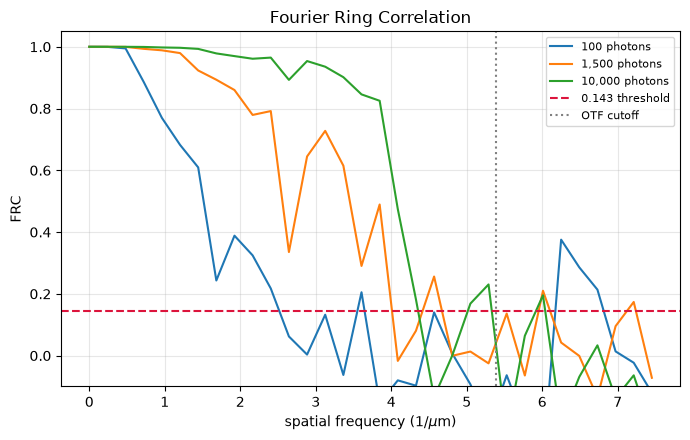

oracle reconstruction, 100 photons      resolution ~  378.2 nm
oracle reconstruction, 1,500 photons    resolution ~  244.7 nm
oracle reconstruction, 10,000 photons   resolution ~  218.9 nm

same photon budget, different PSFs - note they barely differ:
  true PSF       244.7 nm
  wrong PSF      244.7 nm

-> FRC measures the noise-limited resolution, not PSF accuracy.


In [20]:
def two_draws(otf_used, photons=1500.0):
    out = []
    for seed in (11, 12):
        gs = torch.Generator(device=device); gs.manual_seed(seed)
        y = add_noise(blur_t, peak_photons=photons, read_sigma=2.0, generator=gs)
        out.append(normalise_image(apply_wiener(y, otf_used, REG))[0])
    return frc(out[0], out[1])

curves = {
    f"{ph:,} photons": two_draws(otf_from_psf(psf_t), photons=float(ph))
    for ph in (100, 1500, 10000)
}
viz.plot_frc(curves, optics)
plt.show()

for label, curve in curves.items():
    print(f"oracle reconstruction, {label:<16s} resolution ~{frc_resolution_nm(curve, optics):7.1f} nm")

print("\nsame photon budget, different PSFs - note they barely differ:")
for label, otf_used in [("true PSF", otf_from_psf(psf_t)), ("wrong PSF", otf_from_psf(psf_flat))]:
    c = two_draws(otf_used)
    print(f"  {label:<12s} {frc_resolution_nm(c, optics):7.1f} nm")
print("\n-> FRC measures the noise-limited resolution, not PSF accuracy.")

---
## Part 5 — Does it survive real data?

Everything so far was synthetic: the model was trained on simulated objects and
tested on simulated objects drawn from the same generator. That is the easiest
possible situation, and it is not the one that matters.

Now we apply it to **real fluorescence micrographs** the model has never seen —
`human_mitosis` and `kidney` from `skimage.data`, kept strictly out of training.

### An honest caveat

These images are *already blurred* by the microscope that acquired them. Treating
them as sharp ground truth means our synthetic PSF is an additional blur on top
of an unknown existing one. This is standard practice, but it is a real
approximation and worth stating rather than hiding.

training may use: ('cells3d',)
held out:         ('human_mitosis', 'kidney')

human_mitosis: (1, 512, 512)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


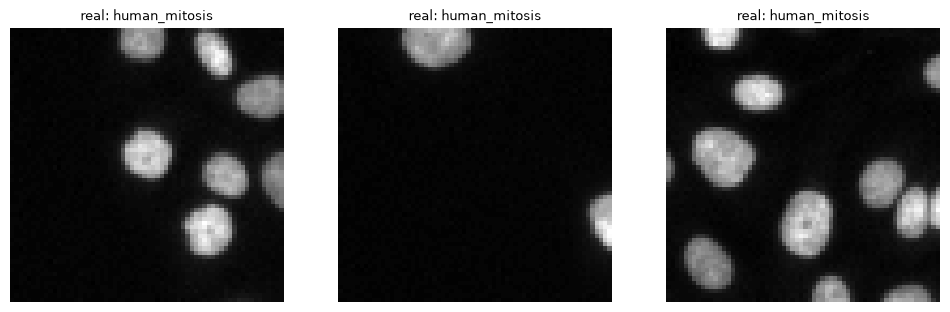

In [21]:
print(f"training may use: {TRAIN_REAL}")
print(f"held out:         {HELD_OUT}")

held = load_held_out("human_mitosis").to(device)
print(f"\nhuman_mitosis: {tuple(held.shape)}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, top in zip(axes, [0, 150, 300]):
    ax.imshow(held[0, top:top+SIZE, top:top+SIZE].cpu(), cmap="gray")
    ax.set_title("real: human_mitosis", fontsize=9); ax.axis("off")
plt.show()

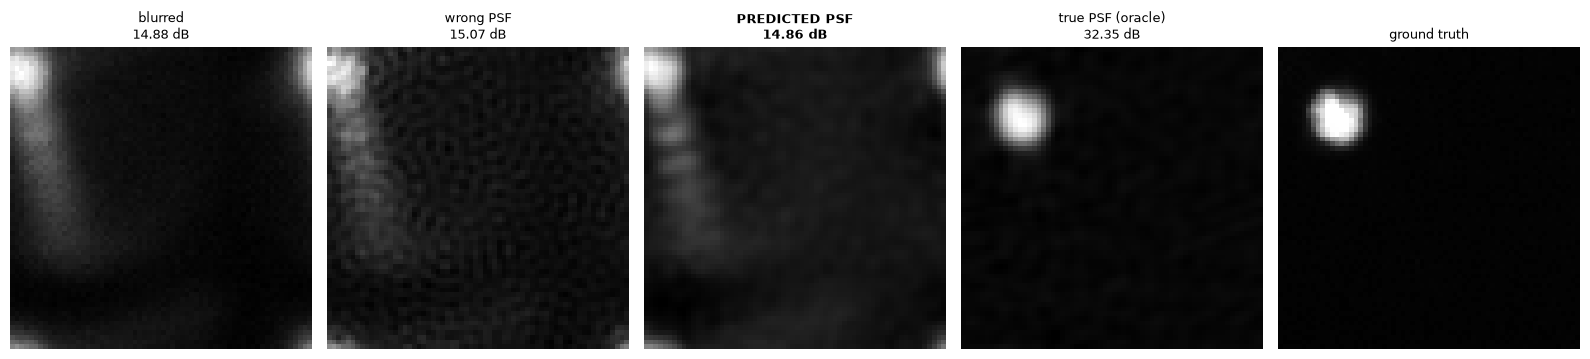

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
QUICK MODE: trained for a few hundred steps. The numbers below are
NOT meaningful science - the model is barely above chance and may
score worse than doing nothing. Set QUICK = False and re-run on a
GPU for real results. Only the PIPELINE is being demonstrated here.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

gap below oracle on synthetic data: 7.34 dB
gap below oracle on real data:      17.49 dB

sim-to-real penalty: +10.15 dB


In [22]:
real_obj = held[0, 100:100+SIZE, 200:200+SIZE][None]
gg = torch.Generator(device=device); gg.manual_seed(5)

c_r = sample_coeffs(1, generator=gg, device=device)
psf_r = center_crop(psf_from_coeffs(c_r, basis, mask), SIZE)
blur_r = convolve_fft(real_obj, otf_from_psf(psf_r))
meas_r = add_noise(blur_r, peak_photons=1500.0, read_sigma=2.0, generator=gg)
meas_rn = normalise_image(meas_r)
truth_r = normalise_image(real_obj)

c_hat_r = denormalise_coeffs(predict_coeffs(model, meas_rn, device=device).cpu()).to(device)
psf_hat_r = center_crop(psf_from_coeffs(c_hat_r, basis, mask), SIZE)

recon_r = {
    "blurred":   meas_rn,
    "naive":     normalise_image(apply_wiener(meas_r, otf_from_psf(psf_flat), REG)),
    "predicted": normalise_image(apply_wiener(meas_r, otf_from_psf(psf_hat_r), REG)),
    "oracle":    normalise_image(apply_wiener(meas_r, otf_from_psf(psf_r), REG)),
}
scores_r = {k: psnr(v, truth_r) for k, v in recon_r.items()}

viz.plot_three_way(recon_r["blurred"][0], recon_r["naive"][0], recon_r["predicted"][0],
                   recon_r["oracle"][0], truth_r[0], scores_r)
plt.show()

quick_warning()
synthetic_gap = scores["oracle"] - scores["predicted"]
real_gap = scores_r["oracle"] - scores_r["predicted"]
print(f"gap below oracle on synthetic data: {synthetic_gap:.2f} dB")
print(f"gap below oracle on real data:      {real_gap:.2f} dB")
print(f"\nsim-to-real penalty: {real_gap - synthetic_gap:+.2f} dB")

### 5.1 Can real data in training close the gap?

Run 3 retrains the winning variant with 10% of its objects drawn from
`cells3d` — real microscopy, but a *different* dataset from the held-out test
images, so the evaluation stays honest.

Only the data mix changes. Architecture, seed, steps and schedule are identical,
so any difference is attributable to the data.

training pool from ('cells3d',): (120, 256, 256)


final loss 0.2875


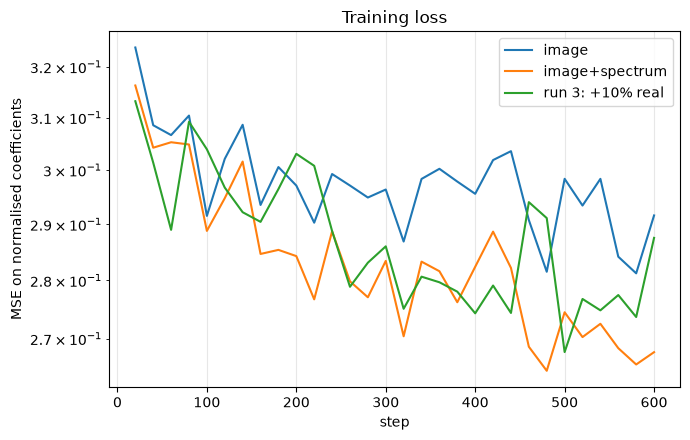

In [23]:
pool = load_training_pool().to(device)
print(f"training pool from {TRAIN_REAL}: {tuple(pool.shape)}")

torch.manual_seed(SEED)
cfg3 = TrainConfig(steps=STEPS, batch=BATCH, size=SIZE, seed=SEED,
                   warmup=max(10, STEPS // 60), log_every=max(1, STEPS // 30),
                   real_fraction=0.10)
model3 = PSFNet(best_variant).to(device)
out3 = train(model3, optics, basis, mask, cfg3, real_pool=pool, device=device, progress=False)
results["run 3: +10% real"] = (out3.steps, out3.losses)
print(f"final loss {out3.final_loss:.4f}")

viz.plot_loss_curves(results)
plt.show()

In [24]:
c_hat_3 = denormalise_coeffs(predict_coeffs(model3, meas_rn, device=device).cpu()).to(device)
psf_hat_3 = center_crop(psf_from_coeffs(c_hat_3, basis, mask), SIZE)
pred_3 = normalise_image(apply_wiener(meas_r, otf_from_psf(psf_hat_3), REG))

print(f"{'model':<28s} {'PSNR on real (dB)':>18s}")
print(f"{'synthetic only':<28s} {scores_r['predicted']:18.2f}")
print(f"{'+ 10% real in training':<28s} {psnr(pred_3, truth_r):18.2f}")
print(f"{'oracle (true PSF)':<28s} {scores_r['oracle']:18.2f}")
print(f"\nchange from adding real data: {psnr(pred_3, truth_r) - scores_r['predicted']:+.2f} dB")

model                         PSNR on real (dB)
synthetic only                            14.86
+ 10% real in training                    14.92
oracle (true PSF)                         32.35

change from adding real data: +0.05 dB


---
## Part 6 — What this leaves out

This is a demonstration, not an instrument. The gaps worth knowing:

**Two dimensions only.** Real fluorescence microscopy is volumetric, and the 3D
PSF is where depth-dependent aberration actually lives. The same machinery
extends, at roughly ten times the compute.

**The PSF is assumed constant across the field.** On a real instrument
aberration varies with position, especially off-axis. Spatially-varying
deconvolution is a substantially harder problem.

**The defocus sign is unrecoverable.** Because the PSF is $|\mathcal{F}\{P\}|^2$,
wavefronts $W$ and its parity inverse give *identical* images. We sidestepped
this by restricting $Z_4 \ge 0$. The real fix is **phase diversity** — capture a
second, deliberately defocused image, which breaks the symmetry. That is what
adaptive-optics systems do.

**Scalar diffraction.** At NA 1.4 the vectorial nature of light measurably
affects the PSF. A production system would use a vectorial model.

**We chose the regularization by hand.** $\lambda$ was set from a known noise
level. A real system must estimate it, or use a method like Richardson–Lucy where
the iteration count plays that role.

**The road not taken.** One could train a network to map blurred images directly
to sharp ones, skipping the PSF entirely — the approach behind CARE and its
descendants. It generally produces better images. It also produces no physical
quantity, no way to check the answer against optics, and no way to tell
hallucinated detail from recovered detail. The choice here trades some
performance for an estimate you can inspect and falsify.

---

### What to take away

The network never learned to sharpen an image. It learned to read an
**aberration** — eight interpretable numbers with names a microscopist would
recognise. The sharpening was done by a Wiener filter that has been understood
since 1949.

That division is deliberate. When the model is wrong, you can see *how* it is
wrong: compare the predicted coefficients to the true ones, look at the
reconstructed PSF, check it against a measured bead. A network that outputs a
sharp image directly offers no such handle.